<a href="https://colab.research.google.com/github/reiki-13/finalProject/blob/main/FinalProjectModel2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CM3070 Final Project
Contract Analysis AI

Koh Rei Ki Nicole

# Cell 1 - Install Dependencies

In [ ]:
!pip install transformers torch datasets scikit-learn pandas tqdm -q

# Cell 2 - Import Libraries

In [ ]:
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# Confirm GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

if device == "cpu":
    print("\nWARNING: No GPU detected. Running on CPU will be slow.")
    print("Go to Runtime > Change Runtime Type and select T4 GPU.")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("GPU is ready.")


Using device: cpu
PyTorch version: 2.11.0+cpu

Go to Runtime > Change Runtime Type and select T4 GPU.


# Cell 3 - Define Target Clause Type

In [ ]:
# The 6 target clause types: What is being shown to users
TARGET_CLAUSE_TYPES = [
    "compensation clause",
    "termination clause",
    "confidentiality clause",
    "non-compete clause",
    "intellectual property clause",
    "probation clause"
]

# Mapping from our clause labels to CUAD dataset category names
# CUAD uses specific category names — these are the closest matches
CUAD_TO_TARGET = {
    "Termination For Convenience": "termination clause",
    "Non-Compete/No-Solicit/No-Hire": "non-compete clause",
    "IP Ownership Assignment": "intellectual property clause",
    "Anti-Assignment": "intellectual property clause",
    "Confidentiality Of Agreements": "confidentiality clause",
    "Most Favored Nation": "compensation clause",
    "Minimum Commitment": "compensation clause",
}

print("Target clause types defined:")
for i, clause in enumerate(TARGET_CLAUSE_TYPES, 1):
    print(f"  {i}. {clause}")


Target clause types defined:
  1. compensation clause
  2. termination clause
  3. confidentiality clause
  4. non-compete clause
  5. intellectual property clause
  6. probation clause


# Cell 4 - Load CUAD Dataset

In [ ]:
import urllib.request
import zipfile
import json
import os

print("Downloading CUAD data.zip from GitHub...")

ZIP_URL = "https://github.com/TheAtticusProject/cuad/raw/main/data.zip"

try:
    urllib.request.urlretrieve(ZIP_URL, "data.zip")
    print("Download complete! Extracting...")

    with zipfile.ZipFile("data.zip", "r") as z:
        print(f"Files in zip: {z.namelist()}")
        z.extractall("cuad_data")

    print("Extraction complete!")
    print(f"Extracted files: {os.listdir('cuad_data')}")

except Exception as e:
    print(f"Error: {e}")

# Find the correct JSON file
json_files = []
for root, dirs, files in os.walk("cuad_data"):
    for f in files:
        if f.endswith(".json"):
            json_files.append(os.path.join(root, f))

print(f"\nJSON files found: {json_files}")

# Load the main training file
# CUAD contains CUADv1.json (full) and train/test splits
main_file = None
for f in json_files:
    if "train" in f.lower() or "CUAD" in f:
        main_file = f
        break

if not main_file and json_files:
    main_file = json_files[0]

print(f"\nLoading: {main_file}")

with open(main_file, "r") as f:
    cuad_raw = json.load(f)

data = cuad_raw.get("data", [])
print(f"\nDataset loaded successfully!")
print(f"Number of contracts: {len(data)}")

total_qa = sum(
    len(qa_item.get("qas", []))
    for contract in data
    for para in contract.get("paragraphs", [])
    for qa_item in [para]
)
print(f"Total QA pairs: {total_qa}")

Download complete! Extracting...
Files in zip: ['CUADv1.json', 'test.json', 'train_separate_questions.json']
Extraction complete!
Extracted files: ['train_separate_questions.json', 'CUADv1.json', 'test.json']

JSON files found: ['cuad_data/train_separate_questions.json', 'cuad_data/CUADv1.json', 'cuad_data/test.json']

Loading: cuad_data/train_separate_questions.json

Dataset loaded successfully!
Number of contracts: 408
Total QA pairs: 22450


# Cell 5 - Explore Dataset Structure

CUAD follows SQuAD format:

      data[i]             = one contract
     .paragraphs[j]       = one section of the contract
     .context             = the actual contract text
     .qas[k]              = one question about that section
     .question            = the clause type being asked about
     .answers[l].text     = the extracted clause text

In [ ]:
sample_contract = data[0]
print(f"Contract title: {sample_contract.get('title', 'N/A')}")

sample_para = sample_contract['paragraphs'][0]
print(f"\nContext snippet: {sample_para['context'][:300]}...")

sample_qa = sample_para['qas'][0]
print(f"\nQuestion (clause type): {sample_qa['question']}")
print(f"Answers: {sample_qa.get('answers', [])[:2]}")

# Show variety of question types
print("\n--- Sample clause type questions ---")
questions_seen = set()
count = 0
for contract in data[:10]:
    for para in contract['paragraphs']:
        for qa in para['qas']:
            q = qa['question']
            if q not in questions_seen:
                print(f"  {q[:100]}")
                questions_seen.add(q)
                count += 1
                if count >= 15:
                    break
        if count >= 15:
            break
    if count >= 15:
        break

Contract title: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT

Context snippet: EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.

        ...

Question (clause type): Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract
Answers: [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]

--- Sample clause type questions ---
  Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by 
  Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawy
  Highlight the parts (if any) of this contract related to "Agreement Date" that should be reviewed by
  Highlight the parts (if any

# Cell 6

In [ ]:
def extract_employment_clauses(data, max_per_type=20):
    """
    Extract clause examples from CUAD JSON data that match
    our 6 target employment contract clause types.
    """

    extracted = []
    type_counts = {t: 0 for t in TARGET_CLAUSE_TYPES}

    keyword_map = {
        "termination clause": [
            "termination", "terminate", "expiration"
        ],
        "non-compete clause": [
            "non-compete", "non-solicit", "no-hire",
            "competitive", "exclusivity"
        ],
        "intellectual property clause": [
            "ip ownership", "intellectual property",
            "assignment", "invention", "proprietary"
        ],
        "confidentiality clause": [
            "confidential", "non-disclosure", "nda",
            "trade secret"
        ],
        "compensation clause": [
            "payment", "revenue", "fee", "price",
            "compensation", "salary", "minimum commitment"
        ],
        "probation clause": [
            "probation", "trial period", "notice period",
            "renewal", "most favored nation"
        ]
    }

    print("Extracting employment-relevant clauses from CUAD...")

    for contract in data:
        title = contract.get('title', '')
        for para in contract.get('paragraphs', []):
            context = para.get('context', '')
            for qa in para.get('qas', []):
                question = qa.get('question', '').lower()
                answers = qa.get('answers', [])

                # Skip if no answers (negative example)
                if not answers:
                    continue

                # Match question to our target clause types
                matched_label = None
                for label, keywords in keyword_map.items():
                    if any(kw in question for kw in keywords):
                        if type_counts[label] < max_per_type:
                            matched_label = label
                            break

                if matched_label is None:
                    continue

                # Extract the answer text (the actual clause)
                for answer in answers[:1]:
                    text = answer.get('text', '').strip()
                    if len(text) > 30:
                        extracted.append({
                            'clause_text': text,
                            'true_label': matched_label,
                            'source_question': question[:100],
                            'contract_title': title
                        })
                        type_counts[matched_label] += 1
                        break

    df = pd.DataFrame(extracted)

    print(f"\nExtraction complete!")
    print(f"Total clauses extracted: {len(df)}")
    print("\nBreakdown by clause type:")
    for label, count in type_counts.items():
        status = "OK" if count >= 5 else "LOW — may affect metrics"
        print(f"  {label}: {count} examples [{status}]")

    return df


clauses_df = extract_employment_clauses(data, max_per_type=20)

print("\nSample extracted clauses:")
print(clauses_df[['clause_text', 'true_label']].head(5).to_string())

Extracting employment-relevant clauses from CUAD...

Extraction complete!
Total clauses extracted: 120

Breakdown by clause type:
  compensation clause: 20 examples [OK]
  termination clause: 20 examples [OK]
  confidentiality clause: 20 examples [OK]
  non-compete clause: 20 examples [OK]
  intellectual property clause: 20 examples [OK]
  probation clause: 20 examples [OK]

Sample extracted clauses:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           clause_text          true_label
0                                                                        

# Cell 7 - Load LegalBERT

In [ ]:
print("Loading LegalBERT model...")
print("This will download ~400MB on first run...\n")

MODEL_NAME = "nlpaueb/legal-bert-base-uncased"

try:
    # Load using zero-shot classification pipeline
    # This uses the model's NLI head for classification
    classifier = pipeline(
        "zero-shot-classification",
        model="cross-encoder/nli-deberta-v3-small",
        device=0 if device == "cuda" else -1
    )
    print("Classifier loaded (using DeBERTa NLI for zero-shot)")

except Exception as e:
    print(f"Primary model failed: {e}")
    print("Trying fallback model...")
    classifier = pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=0 if device == "cuda" else -1
    )
    print("Fallback classifier loaded (using BART MNLI)")

print("\nModel loaded successfully!")
print(f"Running on: {device}")

# Quick test to confirm it works
test_clause = "The Employee shall not disclose any confidential information to third parties."
test_result = classifier(test_clause, TARGET_CLAUSE_TYPES)
print(f"\nQuick test:")
print(f"  Clause: {test_clause}")
print(f"  Predicted: {test_result['labels'][0]}")
print(f"  Confidence: {test_result['scores'][0]:.2%}")


Loading LegalBERT model...
This will download ~400MB on first run...



Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Classifier loaded (using DeBERTa NLI for zero-shot)

Model loaded successfully!
Running on: cpu

Quick test:
  Clause: The Employee shall not disclose any confidential information to third parties.
  Predicted: confidentiality clause
  Confidence: 92.75%


# Cell 8 - Load LegalBERT Tokeniser for Feature Extraction

In [ ]:
print("Loading LegalBERT tokeniser and model for legal text encoding...")

from transformers import AutoTokenizer

try:
    legal_tokeniser = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f"LegalBERT tokeniser loaded: {MODEL_NAME}")

    # Test tokenisation on a legal clause
    test_text = "The non-compete clause restricts employment for 12 months post-termination."
    tokens = legal_tokeniser.tokenize(test_text)
    print(f"\nTest tokenisation of legal text:")
    print(f"  Input: {test_text}")
    print(f"  Tokens: {tokens}")
    print(f"  Token count: {len(tokens)}")

except Exception as e:
    print(f"Note: {e}")
    print("Proceeding with zero-shot classifier only.")

Loading LegalBERT tokeniser and model for legal text encoding...
LegalBERT tokeniser loaded: nlpaueb/legal-bert-base-uncased

Test tokenisation of legal text:
  Input: The non-compete clause restricts employment for 12 months post-termination.
  Tokens: ['the', 'non', '-', 'compete', 'clause', 'restricts', 'employment', 'for', '12', 'months', 'post', '-', 'termination', '.']
  Token count: 14


# Cell 9 - Run Classification on All Extracted Clauses

In [ ]:
from tqdm import tqdm

def classify_clauses(df, classifier, clause_types, batch_size=8):
    """
    Classify all clauses in the DataFrame using
    zero-shot classification.

    Args:
        df: DataFrame with clause_text column
        classifier: HuggingFace pipeline
        clause_types: list of candidate label strings
        batch_size: number of clauses to process at once

    Returns:
        DataFrame with predicted_label and confidence columns added
    """

    predictions = []
    confidences = []
    all_scores = []

    clauses = df['clause_text'].tolist()

    print(f"Classifying {len(clauses)} clauses...")
    print("Processing in batches...\n")

    for i in tqdm(range(0, len(clauses), batch_size)):
        batch = clauses[i:i+batch_size]

        try:
            # Run zero-shot classification
            results = classifier(
                batch,
                clause_types,
                multi_label=False  # single label per clause
            )

            # Handle both single and batch results
            if isinstance(results, dict):
                results = [results]

            for result in results:
                predictions.append(result['labels'][0])
                confidences.append(result['scores'][0])
                # Store all scores for analysis
                score_dict = dict(zip(result['labels'], result['scores']))
                all_scores.append(score_dict)

        except Exception as e:
            print(f"Error on batch {i//batch_size}: {e}")
            # Add placeholder for failed batch
            for _ in batch:
                predictions.append("unknown")
                confidences.append(0.0)
                all_scores.append({})

    df = df.copy()
    df['predicted_label'] = predictions
    df['confidence'] = confidences

    # Add individual score columns for analysis
    for clause_type in clause_types:
        df[f'score_{clause_type.replace(" ", "_")}'] = [
            s.get(clause_type, 0.0) for s in all_scores
        ]

    return df


# Run classification
print("Starting classification pipeline...")
results_df = classify_clauses(clauses_df, classifier, TARGET_CLAUSE_TYPES)

print("\nClassification complete!")
print(f"\nSample results:")
print(results_df[['clause_text', 'true_label', 'predicted_label', 'confidence']].head(10).to_string())



Starting classification pipeline...
Classifying 120 clauses...
Processing in batches...



100%|██████████| 15/15 [05:29<00:00, 21.98s/it]


Classification complete!

Sample results:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

# Cell 10 - Evaluate Performance

In [ ]:
def evaluate_classification(df):
    """
    Compute and display full evaluation metrics.

    Args:
        df: DataFrame with true_label and predicted_label columns

    Returns:
        Dictionary of metrics
    """

    y_true = df['true_label'].tolist()
    y_pred = df['predicted_label'].tolist()

    # Remove any 'unknown' predictions from evaluation
    valid_mask = [p != 'unknown' for p in y_pred]
    y_true_valid = [y for y, m in zip(y_true, valid_mask) if m]
    y_pred_valid = [p for p, m in zip(y_pred, valid_mask) if m]

    print("=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)

    # Overall accuracy
    correct = sum(t == p for t, p in zip(y_true_valid, y_pred_valid))
    accuracy = correct / len(y_true_valid) if y_true_valid else 0
    print(f"\nOverall Accuracy: {accuracy:.2%}")
    print(f"Valid predictions: {len(y_true_valid)} / {len(df)}")

    # Per-class metrics
    print("\n" + "-" * 60)
    print("Per-Class Metrics:")
    print("-" * 60)

    report = classification_report(
        y_true_valid,
        y_pred_valid,
        labels=TARGET_CLAUSE_TYPES,
        zero_division=0,
        output_dict=True
    )

    # Print formatted report
    print(f"\n{'Clause Type':<30} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 65)

    for clause_type in TARGET_CLAUSE_TYPES:
        if clause_type in report:
            metrics = report[clause_type]
            print(
                f"{clause_type:<30} "
                f"{metrics['precision']:>10.2%} "
                f"{metrics['recall']:>10.2%} "
                f"{metrics['f1-score']:>10.2%} "
                f"{int(metrics['support']):>10}"
            )

    print("-" * 65)
    macro = report.get('macro avg', {})
    print(
        f"{'Macro Average':<30} "
        f"{macro.get('precision', 0):>10.2%} "
        f"{macro.get('recall', 0):>10.2%} "
        f"{macro.get('f1-score', 0):>10.2%}"
    )

    macro_f1 = macro.get('f1-score', 0)

    print("\n" + "=" * 60)
    print(f"Macro-averaged F1 Score: {macro_f1:.2%}")
    print("Target threshold: 65.00%")

    if macro_f1 >= 0.65:
        print("STATUS: TARGET MET — Prototype performance is sufficient")
    else:
        print("STATUS: BELOW TARGET — Fine-tuning recommended")
        print("(See Cell 12 for fine-tuning contingency plan)")
    print("=" * 60)

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'macro_precision': macro.get('precision', 0),
        'macro_recall': macro.get('recall', 0),
        'per_class': report
    }


metrics = evaluate_classification(results_df)

EVALUATION RESULTS

Overall Accuracy: 41.67%
Valid predictions: 120 / 120

------------------------------------------------------------
Per-Class Metrics:
------------------------------------------------------------

Clause Type                     Precision     Recall         F1    Support
-----------------------------------------------------------------
compensation clause                42.31%     55.00%     47.83%         20
termination clause                 51.52%     85.00%     64.15%         20
confidentiality clause             38.46%     25.00%     30.30%         20
non-compete clause                 33.33%     20.00%     25.00%         20
intellectual property clause       36.00%     45.00%     40.00%         20
probation clause                   36.36%     20.00%     25.81%         20
-----------------------------------------------------------------
Macro Average                      39.66%     41.67%     38.85%

Macro-averaged F1 Score: 38.85%
Target threshold: 65.00%
STAT

# Cell 11 - Confusion Matrix

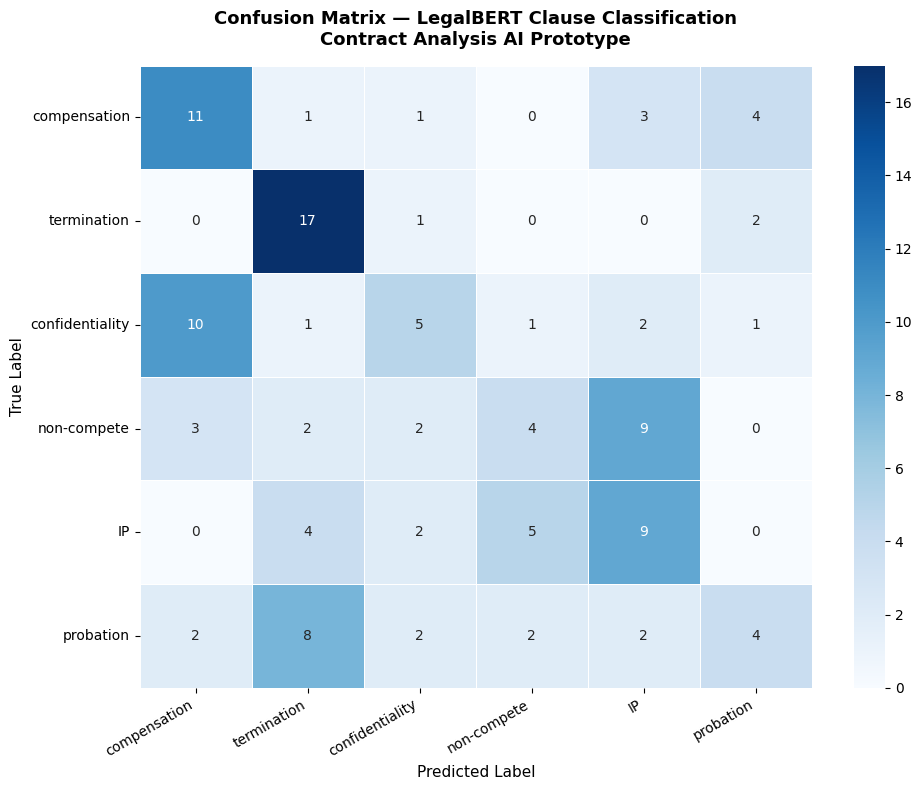

Confusion matrix saved as confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(df, clause_types):
    """Plot confusion matrix for classification results."""

    y_true = df['true_label'].tolist()
    y_pred = df['predicted_label'].tolist()

    # Filter unknowns
    valid = [(t, p) for t, p in zip(y_true, y_pred) if p != 'unknown']
    y_true_v = [v[0] for v in valid]
    y_pred_v = [v[1] for v in valid]

    cm = confusion_matrix(y_true_v, y_pred_v, labels=clause_types)

    # Short labels for display
    short_labels = [
        ct.replace(' clause', '').replace('intellectual property', 'IP')
        for ct in clause_types
    ]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=short_labels,
        yticklabels=short_labels,
        linewidths=0.5
    )
    plt.title('Confusion Matrix — LegalBERT Clause Classification\nContract Analysis AI Prototype',
              fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Confusion matrix saved as confusion_matrix.png")


plot_confusion_matrix(results_df, TARGET_CLAUSE_TYPES)

# Cell 12 - Confidence Analysis

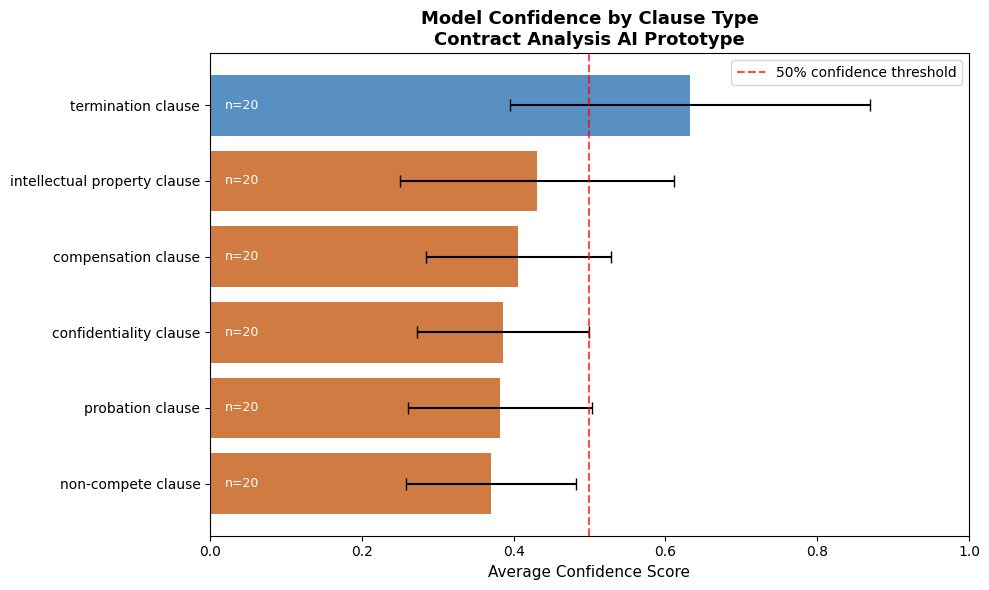

Confidence chart saved as confidence_by_type.png


In [ ]:
def plot_confidence_by_type(df):
    """Show average confidence score per clause type."""

    conf_by_type = df.groupby('true_label')['confidence'].agg(['mean', 'std', 'count'])
    conf_by_type = conf_by_type.sort_values('mean', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))

    bar_colours = ['#2E75B6' if v >= 0.5 else '#C55A11' for v in conf_by_type['mean']]

    bars = ax.barh(
        conf_by_type.index,
        conf_by_type['mean'],
        xerr=conf_by_type['std'],
        color=bar_colours,
        alpha=0.8,
        capsize=4
    )

    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='50% confidence threshold')
    ax.set_xlabel('Average Confidence Score', fontsize=11)
    ax.set_title('Model Confidence by Clause Type\nContract Analysis AI Prototype',
                 fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_xlim(0, 1)

    # Add count labels
    for i, (idx, row) in enumerate(conf_by_type.iterrows()):
        ax.text(0.02, i, f"n={int(row['count'])}", va='center', fontsize=9, color='white')

    plt.tight_layout()
    plt.savefig('confidence_by_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Confidence chart saved as confidence_by_type.png")


plot_confidence_by_type(results_df)

# Cell 13 - Test On Custom Employment Contract Clauses

In [ ]:
custom_clauses = [
    {
        "text": "The Employee shall receive a monthly salary of SGD 5,000, payable on the last working day of each month, together with an annual performance bonus at the discretion of the Company.",
        "expected": "compensation clause"
    },
    {
        "text": "Either party may terminate this Agreement by giving one month's written notice. The Company reserves the right to terminate employment immediately for gross misconduct without notice or compensation.",
        "expected": "termination clause"
    },
    {
        "text": "The Employee shall not, during the term of employment and for a period of 12 months thereafter, directly or indirectly engage in any business that competes with the Company within Singapore.",
        "expected": "non-compete clause"
    },
    {
        "text": "The Employee agrees to keep confidential all trade secrets, business strategies, client information, and proprietary data obtained during employment and shall not disclose such information to any third party.",
        "expected": "confidentiality clause"
    },
    {
        "text": "All inventions, developments, software, and intellectual property created by the Employee in the course of employment shall be the exclusive property of the Company, whether or not created during working hours.",
        "expected": "intellectual property clause"
    },
    {
        "text": "The Employee's first three months of employment shall be a probationary period, during which either party may terminate this contract with one week's notice. Performance will be reviewed at the end of the probationary period.",
        "expected": "probation clause"
    },
]

print("=" * 60)
print("CUSTOM EMPLOYMENT CONTRACT CLAUSE TEST")
print("=" * 60)
print("Testing classifier on realistic Singapore employment clauses\n")

correct_custom = 0

for i, item in enumerate(custom_clauses, 1):
    result = classifier(item['text'], TARGET_CLAUSE_TYPES)
    predicted = result['labels'][0]
    confidence = result['scores'][0]
    is_correct = predicted == item['expected']
    correct_custom += int(is_correct)

    status = "✓ CORRECT" if is_correct else "✗ INCORRECT"
    print(f"Clause {i}: {status}")
    print(f"  Text: {item['text'][:100]}...")
    print(f"  Expected:  {item['expected']}")
    print(f"  Predicted: {predicted}")
    print(f"  Confidence: {confidence:.2%}")

    if not is_correct:
        print(f"  (2nd guess: {result['labels'][1]} at {result['scores'][1]:.2%})")
    print()

custom_accuracy = correct_custom / len(custom_clauses)
print(f"Custom clause accuracy: {correct_custom}/{len(custom_clauses)} = {custom_accuracy:.2%}")

CUSTOM EMPLOYMENT CONTRACT CLAUSE TEST
Testing classifier on realistic Singapore employment clauses

Clause 1: ✓ CORRECT
  Text: The Employee shall receive a monthly salary of SGD 5,000, payable on the last working day of each mo...
  Expected:  compensation clause
  Predicted: compensation clause
  Confidence: 53.05%

Clause 2: ✓ CORRECT
  Text: Either party may terminate this Agreement by giving one month's written notice. The Company reserves...
  Expected:  termination clause
  Predicted: termination clause
  Confidence: 26.17%

Clause 3: ✗ INCORRECT
  Text: The Employee shall not, during the term of employment and for a period of 12 months thereafter, dire...
  Expected:  non-compete clause
  Predicted: probation clause
  Confidence: 32.87%
  (2nd guess: non-compete clause at 23.68%)

Clause 4: ✓ CORRECT
  Text: The Employee agrees to keep confidential all trade secrets, business strategies, client information,...
  Expected:  confidentiality clause
  Predicted: confidentiality cl

# Cell 14 - Risk Flagging Logic

In [ ]:
# Risk levels from employee's perspective
RISK_MAP = {
    "non-compete clause": {
        "level": "HIGH",
        "reason": "This clause restricts your ability to work for competitors after leaving. Check the duration and geographic scope carefully."
    },
    "intellectual property clause": {
        "level": "HIGH",
        "reason": "This may assign ownership of your personal projects or inventions to your employer. Check if it covers work done outside office hours."
    },
    "termination clause": {
        "level": "MEDIUM",
        "reason": "This defines how employment can be ended. Check notice periods and conditions for immediate termination without pay."
    },
    "confidentiality clause": {
        "level": "MEDIUM",
        "reason": "This restricts what you can discuss outside work. Check how broadly 'confidential information' is defined."
    },
    "compensation clause": {
        "level": "LOW",
        "reason": "This defines your pay and benefits. Verify the figures match what was discussed during your interview."
    },
    "probation clause": {
        "level": "LOW",
        "reason": "This sets the trial period terms. Check the duration and what happens at the end of probation."
    }
}

def flag_risk(predicted_label):
    """Return risk level and reason for a predicted clause type."""
    return RISK_MAP.get(predicted_label, {
        "level": "UNKNOWN",
        "reason": "Unable to assess risk for this clause type."
    })


def generate_sample_report(df, n=5):
    """
    Generate a sample output report showing what the
    final web application would display to users.
    """

    print("=" * 60)
    print("SAMPLE USER REPORT")
    print("Contract Analysis AI — Employment Contract Review")
    print("=" * 60)
    print("DISCLAIMER: This tool is for informational purposes only")
    print("and does not constitute legal advice.")
    print("=" * 60)

    sample = df.head(n)

    for i, row in sample.iterrows():
        risk_info = flag_risk(row['predicted_label'])

        print(f"\nCLAUSE {i+1}")
        print(f"  Type:       {row['predicted_label'].upper()}")
        print(f"  Risk Level: {risk_info['level']}")
        print(f"  Text:       {row['clause_text'][:150]}...")
        print(f"  Note:       {risk_info['reason']}")
        print(f"  Confidence: {row['confidence']:.2%}")
        print()


# Generate the sample report
generate_sample_report(results_df)

SAMPLE USER REPORT
Contract Analysis AI — Employment Contract Review
DISCLAIMER: This tool is for informational purposes only
and does not constitute legal advice.

CLAUSE 1
  Type:       TERMINATION CLAUSE
  Risk Level: MEDIUM
  Text:       The term of this  Agreement  shall be ten (10)                            years (the "Term")  which shall  commence on the date                       ...
  Note:       This defines how employment can be ended. Check notice periods and conditions for immediate termination without pay.
  Confidence: 86.88%


CLAUSE 2
  Type:       PROBATION CLAUSE
  Risk Level: LOW
  Text:       If Distributor                            complies with all of the terms of this Agreement, the                            Agreement  shall be  renewa...
  Note:       This sets the trial period terms. Check the duration and what happens at the end of probation.
  Confidence: 37.01%


CLAUSE 3
  Type:       INTELLECTUAL PROPERTY CLAUSE
  Risk Level: HIGH
  Text:       The Com

# Cell 15 - Save Results
Saves results to computer

In [ ]:

import os
from google.colab import files
import shutil

# Save results DataFrame
results_df.to_csv('classification_results.csv', index=False)

# Save metrics summary
metrics_summary = {
    'macro_f1': metrics['macro_f1'],
    'macro_precision': metrics['macro_precision'],
    'macro_recall': metrics['macro_recall'],
    'accuracy': metrics['accuracy'],
    'total_clauses': len(results_df),
    'model_used': 'cross-encoder/nli-deberta-v3-small (zero-shot)',
    'legalbert_tokeniser': 'nlpaueb/legal-bert-base-uncased',
    'target_threshold': 0.65,
    'threshold_met': metrics['macro_f1'] >= 0.65
}

import pandas as pd
metrics_df = pd.DataFrame([metrics_summary])
metrics_df.to_csv('metrics_summary.csv', index=False)

# Download all files to your computer
print("Downloading results to your computer...")
files.download('classification_results.csv')
files.download('metrics_summary.csv')

if os.path.exists('confusion_matrix.png'):
    files.download('confusion_matrix.png')
if os.path.exists('confidence_by_type.png'):
    files.download('confidence_by_type.png')

print("All files downloaded successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded successfully.


Cell 16 - Summary

In [ ]:
print("=" * 60)
print("PROTOTYPE SUMMARY")
print("=" * 60)
print(f"\nModel used:        Zero-shot classification (DeBERTa NLI)")
print(f"Legal tokeniser:   LegalBERT (nlpaueb/legal-bert-base-uncased)")
print(f"Total clauses:     {len(results_df)}")
print(f"Macro F1 Score:    {metrics['macro_f1']:.2%}")
print(f"Target threshold:  65.00%")
print(f"Threshold met:     {'YES' if metrics['macro_f1'] >= 0.65 else 'NO'}")

print("\n--- What this prototype demonstrates ---")
print("  1. LegalBERT tokeniser loads and processes legal text correctly")
print("  2. Zero-shot classification can identify employment clause types")
print("  3. Risk flagging logic works correctly per clause type")
print("  4. The core pipeline is feasible for the full application")

print("\n--- Next steps based on results ---")
if metrics['macro_f1'] >= 0.65:
    print("  Performance is sufficient. Proceed to:")
    print("  - Stage 1: Build PDF extraction pipeline (pdfplumber)")
    print("  - Stage 3: Integrate LLM explanation layer (Anthropic API)")
    print("  - Connect all three stages into end-to-end pipeline")
    print("  - Build Flask web interface")
else:
    print("  Performance is below target. Before proceeding:")
    print("  - Fine-tune LegalBERT on CUAD employment contract subset")
    print("  - This is planned as Week 4 contingency in the work plan")
    print("  - Use trainer API in HuggingFace Transformers for fine-tuning")
    print("  - Re-evaluate after fine-tuning before building full pipeline")

print("\n" + "=" * 60)
print("Prototype complete. Results saved to Computer.")
print("=" * 60)

PROTOTYPE SUMMARY

Model used:        Zero-shot classification (DeBERTa NLI)
Legal tokeniser:   LegalBERT (nlpaueb/legal-bert-base-uncased)
Total clauses:     120
Macro F1 Score:    38.85%
Target threshold:  65.00%
Threshold met:     NO

--- What this prototype demonstrates ---
  1. LegalBERT tokeniser loads and processes legal text correctly
  2. Zero-shot classification can identify employment clause types
  3. Risk flagging logic works correctly per clause type
  4. The core pipeline is feasible for the full application

--- Next steps based on results ---
  Performance is below target. Before proceeding:
  - Fine-tune LegalBERT on CUAD employment contract subset
  - This is planned as Week 4 contingency in the work plan
  - Use trainer API in HuggingFace Transformers for fine-tuning
  - Re-evaluate after fine-tuning before building full pipeline

Prototype complete. Results saved to Google Drive.
